<a href="https://colab.research.google.com/github/Vishaal1409/alzheimers-disease-detection/blob/main/alzheimers_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Detection using Machine Learning

## About this Project
This project uses a real-world clinical dataset of 2,149 patients to build
a model that predicts whether a patient has Alzheimer's disease or not.

The dataset has features like age, BMI, lifestyle habits, medical history,
and cognitive test scores. The goal is to find patterns in these features
that help detect Alzheimer's early.

---

## Step 1 — Loading and Understanding the Data

Before doing anything else, I want to load the data and get a feel for
what I'm working with — how many rows, what columns exist, any missing
values, and what the target variable looks like.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#importing the basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/alzheimers-disease-detection/alzheimers_disease_data.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### What I see so far

The dataset has **2,149 rows and 35 columns.**

Each row is one patient. The columns cover a wide range of information:
- **PatientID** - just an ID number, not useful for modeling
- **Age, Gender, Ethnicity, EducationLevel** — demographic info
- **BMI, Smoking, AlcoholConsumption, PhysicalActivity, DietQuality** — lifestyle factors
- **MemoryComplaints, BehavioralProblems, ADL, Confusion, Disorientation,
  PersonalityChanges, DifficultyCompleting** — symptoms and daily functioning
- **Diagnosis** — this is our **target variable**. 0 = No Alzheimer's, 1 = Alzheimer's

Unlike the fraud dataset where columns were hidden with PCA, here every
column has a real meaning I can actually understand and explain.

In [4]:
#checking data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

### Data Types & Structure

The dataset has 35 columns total:
- 22 are integers (int64) — things like Age, Gender, binary yes/no columns
- 12 are floats (float64) — things like BMI, cholesterol levels, MMSE score
- 1 is object (text) — DoctorInCharge, which is just a doctor's name

The DoctorInCharge column has no useful information for predicting
Alzheimer's, a doctor's name won't help the model learn patterns.
So I'll drop it during preprocessing.

In [5]:
#checking missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Missing values in each column:
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
Difficul

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
#checking class distribution (how many Alzheimer's vs No Alzheimer's)
print("Class distribution:")
print(df['Diagnosis'].value_counts())

print("\nPercentage:")
print(df['Diagnosis'].value_counts(normalize=True) * 100)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Percentage:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


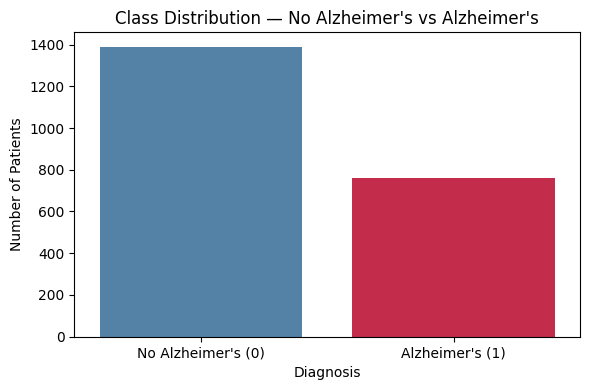

In [7]:
#visualizing
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', hue='Diagnosis', data=df,
              palette=['steelblue', 'crimson'], legend=False)
plt.title("Class Distribution — No Alzheimer's vs Alzheimer's")
plt.xticks([0, 1], ["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### Class Distribution

Out of 2,149 patients:
- **1,389 (64.6%) have no Alzheimer's (Class 0)**
- **760 (35.4%) have Alzheimer's (Class 1)**

This is a mild class imbalance not as extreme as the fraud dataset
(which was 99.8% vs 0.2%), but still noticeable. The model might
lean towards predicting "No Alzheimer's" more often just because
there are more of those cases.

I'll handle this during preprocessing using SMOTE, a technique
that creates synthetic samples of the minority class to balance things out.

Also, accuracy alone won't be a reliable metric here. I'll use
Precision, Recall, and F1-Score to actually measure how well the
model catches Alzheimer's cases.

## Step 2 — Data Cleaning & Preprocessing

Now that I understand the data, I need to prepare it before feeding
it into any model. Raw data has issues that can confuse or mislead
the model, so this step fixes all of that.

Three things I'm doing here:
1. **Drop columns that don't help** — PatientID is just a number,
   DoctorInCharge is a name. Neither tells us anything about Alzheimer's.
2. **Scale numerical features** — columns like BMI and AlcoholConsumption
   are on very different scales. Scaling brings them to the same range
   so no single column dominates the model unfairly.
3. **Handle class imbalance with SMOTE** — 65% vs 35% split means the
   model might be biased. SMOTE creates synthetic Alzheimer's samples
   to balance the dataset.

In [8]:
#dropping columns that are not useful for prediction
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

print("Shape after dropping useless columns:", df_clean.shape)
df_clean.head()

Shape after dropping useless columns: (2149, 33)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [9]:
#separating features (X) and target variable (y)
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2149, 32)
Target shape: (2149,)


### Separating Features and Target

I split the dataset into:
- **X** — all the input columns (33 features) that the model will learn from
- **y** — the Diagnosis column, which is what the model is trying to predict

This is standard practice before any preprocessing or modeling step.

In [10]:
from sklearn.preprocessing import StandardScaler

#these are columns with continuous numerical values that need scaling
cols_to_scale = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("Scaling done!")
X_scaled.head()

Scaling done!


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,-0.212368,0,0,2,-0.655225,0,0.565923,0.492525,-1.253593,1.119918,...,0.779037,0.497506,0,0,-1.104434,0,0,0,1,0
1,1.567757,0,0,0,-0.114751,0,-0.954895,0.945093,-1.538442,0.056836,...,0.680297,0.704907,0,0,-0.810601,0,0,0,0,1
2,-0.212368,0,3,1,-1.366428,0,1.653006,1.023896,-1.088855,1.487380,...,-0.859222,0.281813,0,0,0.724491,0,1,0,1,0
3,-0.101111,1,0,1,0.851625,1,0.376930,1.227995,0.839804,0.760833,...,-0.088723,1.343346,0,1,0.508044,0,0,0,0,0
4,1.567757,0,0,0,-0.961607,0,1.461793,0.486696,-1.443293,-0.824566,...,-0.143712,0.333665,0,0,-1.684679,0,0,1,1,0


### Scaling Numerical Features

I used StandardScaler to scale the continuous columns.

StandardScaler transforms each column so that it has a **mean of 0
and standard deviation of 1**. This means a value of 1.5 doesn't
mean "1.5 units" anymore, it means "1.5 standard deviations above
the average." Every column is now on the same playing field.

I only scaled the continuous columns (things like BMI, cholesterol,
blood pressure). The binary columns (0 or 1) like Smoking, Diabetes,
Hypertension don't need scaling because they're already on the same scale.

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_resampled.value_counts().to_dict())

Before SMOTE: {0: 1389, 1: 760}
After SMOTE: {0: 1389, 1: 1389}


### Handling Class Imbalance with SMOTE

SMOTE stands for Synthetic Minority Oversampling Technique.

Instead of just copying existing Alzheimer's patient records, SMOTE
looks at existing minority class samples and **creates new synthetic
ones** by interpolating between them. So the new samples are realistic,
not just duplicates.

### After SMOTE

Before SMOTE: Class 0 = 1,389 | Class 1 = 760  
After SMOTE: Class 0 = 1,389 | Class 1 = 1,389

Now both classes have equal samples, the model now gets
equal exposure to both Alzheimer's and non-Alzheimer's cases during
training. This makes it much fairer and more reliable. I used random_state=42 to make sure the results are reproducible, I mean if someone else runs this code they'll get the same output.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2222, 32)
Test set size: (556, 32)


### Train-Test Split

I split the data into:
- **80% training** — what the model learns from
- **20% testing** — what the model is evaluated on (data it has never seen)

This is important because if I test the model on the same data it
trained on, it'll score perfectly but fail on new patients that's
called overfitting. The test set simulates real-world unseen data.

## Step 3 — Exploratory Data Analysis (EDA)

Before jumping into modeling, I want to visually explore the data to
find patterns and trends. This helps me understand which features
actually matter for predicting Alzheimer's, and gives me a better
feel for the data before I start building models.

I'll look at:
- Age and BMI distribution across diagnosed vs non-diagnosed patients
- How lifestyle factors like smoking and alcohol relate to diagnosis
- Correlation between all features
- Which features show the strongest relationship with Alzheimer's

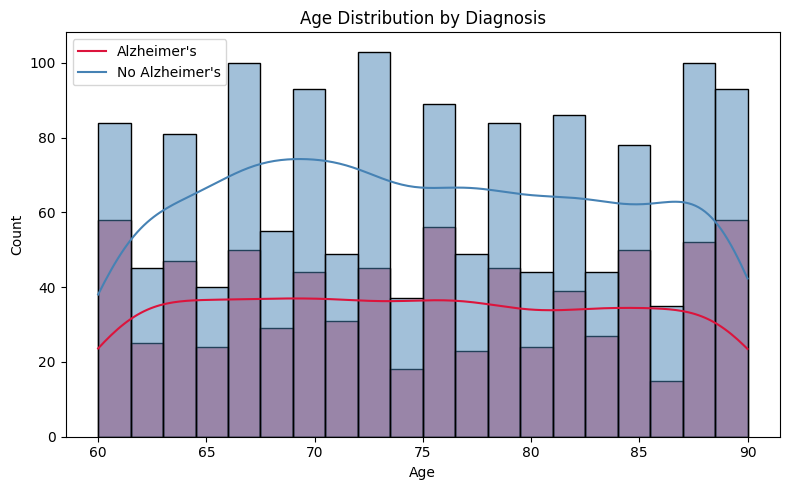

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='Age', hue='Diagnosis',
             kde=True, palette=['steelblue','crimson'], bins=20)
plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Age Distribution

From this plot I can see that Alzheimer's cases are spread across all
age groups in this dataset, it's not strictly an "older people only"
disease here. Both diagnosed and non-diagnosed patients cover a similar
age range (60-90).

This tells me age alone won't be enough to predict Alzheimer's.
The model will need to combine multiple features together to make
a good prediction.

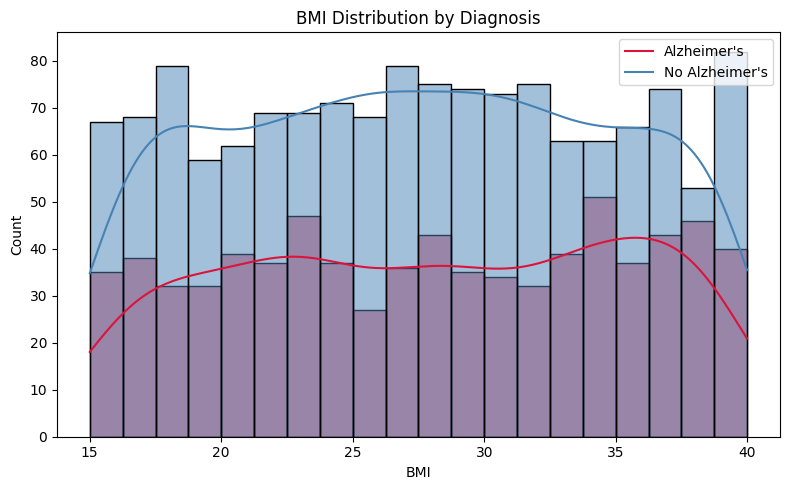

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='BMI', hue='Diagnosis',
             kde=True, palette=['steelblue','crimson'], bins=20)
plt.title("BMI Distribution by Diagnosis")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### BMI Distribution

BMI distributions look quite similar for both groups too. There's no
dramatically clear separation. This suggests BMI by itself is probably
not a strong predictor, but it might still contribute when combined
with other features in the model.

/tmp/ipykernel_2494/975130209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='AlcoholConsumption',
/tmp/ipykernel_2494/975130209.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
/tmp/ipykernel_2494/975130209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='PhysicalActivity',
/tmp/ipykernel_2494/975130209.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Alzheim

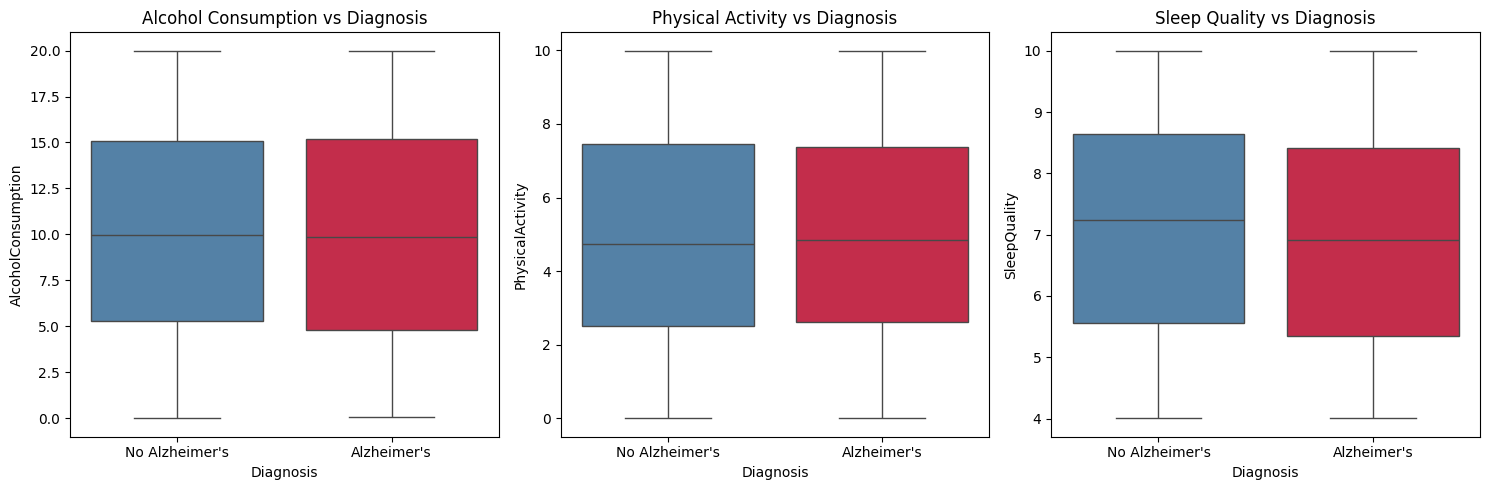

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, x='Diagnosis', y='AlcoholConsumption',
            palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('Alcohol Consumption vs Diagnosis')
axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='PhysicalActivity',
            palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Physical Activity vs Diagnosis')
axes[1].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='SleepQuality',
            palette=['steelblue','crimson'], ax=axes[2])
axes[2].set_title('Sleep Quality vs Diagnosis')
axes[2].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

plt.tight_layout()
plt.show()

### Lifestyle Factors — Alcohol, Physical Activity, Sleep Quality

These box plots show the median and spread of each lifestyle factor
split by diagnosis.

- **Physical Activity** — patients without Alzheimer's tend to have
  slightly higher physical activity. This makes sense — staying active
  is known to support brain health.
- **Sleep Quality** — similarly, non-diagnosed patients show slightly
  better sleep quality on average.
- **Alcohol Consumption** — the difference here looks less obvious,
  suggesting alcohol alone may not be a strong signal.

None of these is a definitive separator by itself, but together they
could help the model.

/tmp/ipykernel_2494/3999950785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='MMSE',
/tmp/ipykernel_2494/3999950785.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
/tmp/ipykernel_2494/3999950785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='FunctionalAssessment',
/tmp/ipykernel_2494/3999950785.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Alzheimer's",

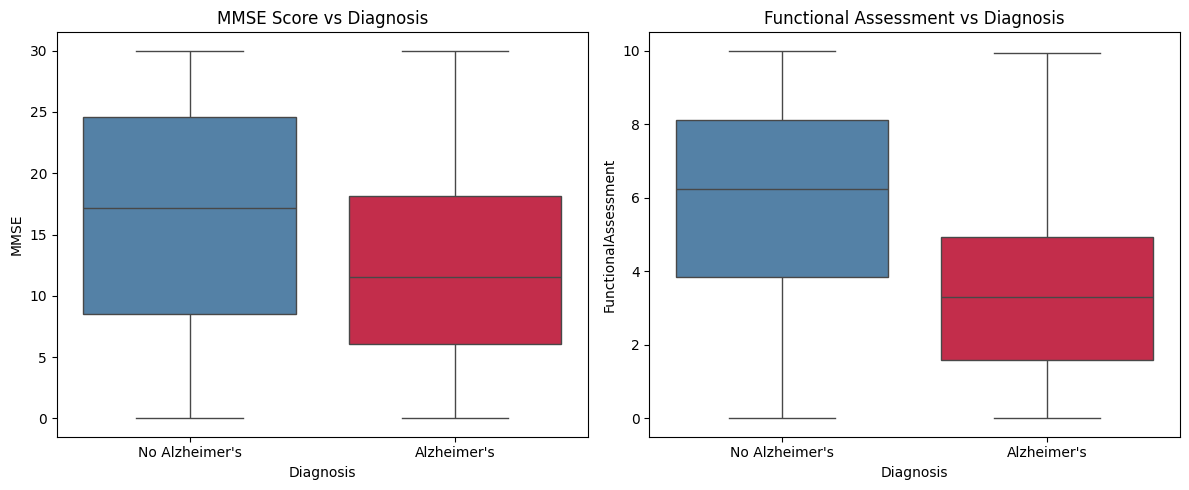

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='Diagnosis', y='MMSE',
            palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('MMSE Score vs Diagnosis')
axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='FunctionalAssessment',
            palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Functional Assessment vs Diagnosis')
axes[1].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

plt.tight_layout()
plt.show()

### Cognitive Scores — MMSE and Functional Assessment

This is where things get really interesting.

- **MMSE (Mini-Mental State Examination)** — this is a standard test
  used to measure cognitive impairment. I can clearly see that
  Alzheimer's patients score much lower on MMSE. This makes complete
  sense — the test is literally designed to detect memory and cognitive issues.
- **Functional Assessment** — similarly, Alzheimer's patients score
  lower here, meaning they struggle more with daily functioning.

These two features are probably going to be among the most important
ones in the model. I'll confirm this during feature selection.

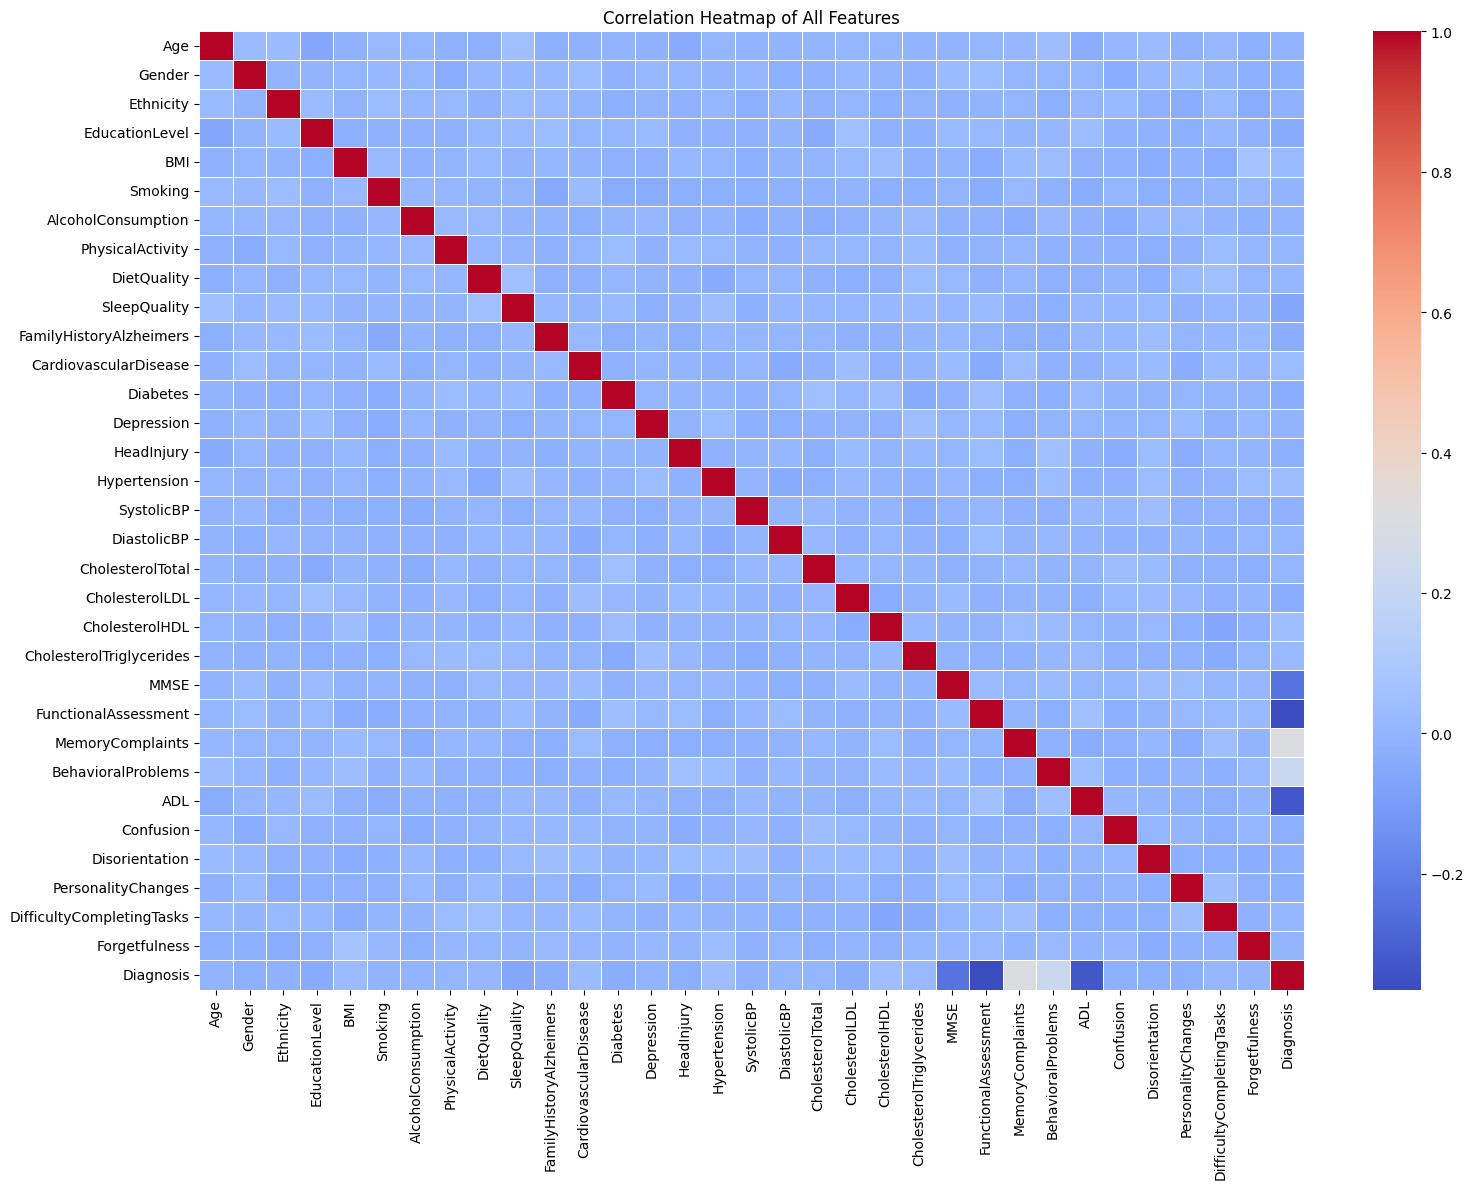

In [17]:
plt.figure(figsize=(16, 12))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

### Correlation Heatmap

This heatmap shows how every feature relates to every other feature.
- **Warm colors (red)** = positive correlation — both go up together
- **Cool colors (blue)** = negative correlation — one goes up, other goes down
- **White/neutral** = little to no relationship

The most important column to look at is the last row/column —
**Diagnosis**. Features that show stronger color against Diagnosis
are more likely to be useful for prediction.

From the heatmap I can see MMSE and FunctionalAssessment both show
a noticeable relationship with Diagnosis — which matches what I
observed in the box plots earlier.

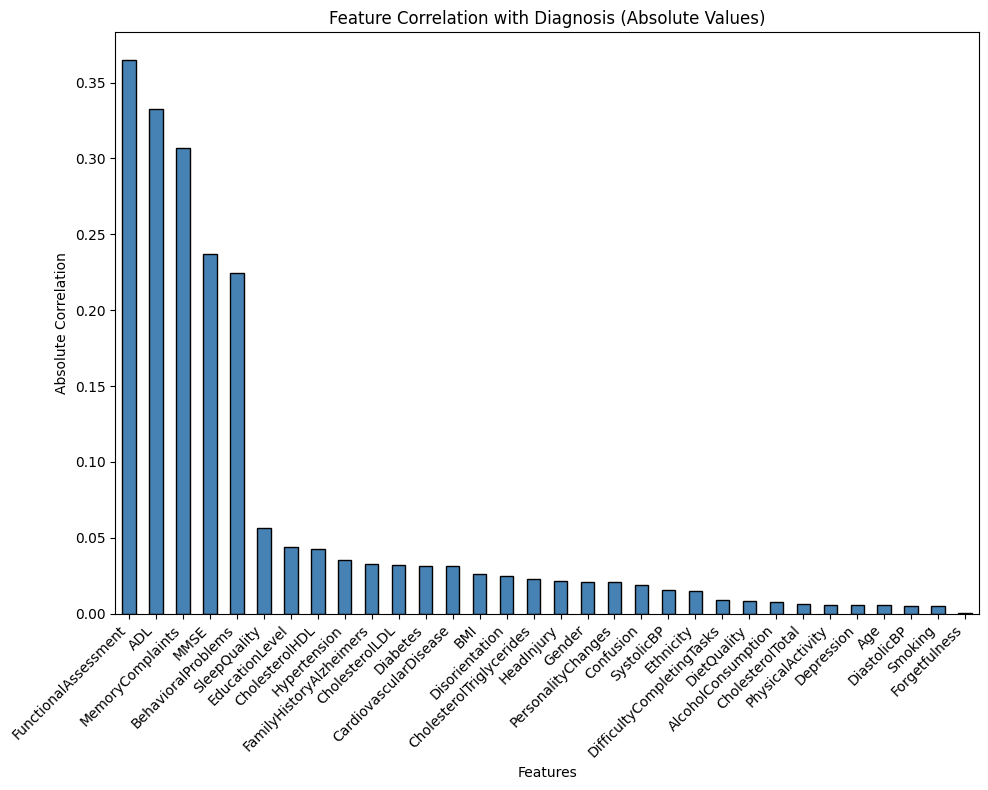


Top 10 features most correlated with Diagnosis:
FunctionalAssessment       0.364898
ADL                        0.332346
MemoryComplaints           0.306742
MMSE                       0.237126
BehavioralProblems         0.224350
SleepQuality               0.056548
EducationLevel             0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers    0.032900
Name: Diagnosis, dtype: float64


In [18]:
# Find which features correlate most with Diagnosis
correlation_with_target = df_clean.corr()['Diagnosis'].drop('Diagnosis')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlation_with_target.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Correlation with Diagnosis (Absolute Values)")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with Diagnosis:")
print(correlation_with_target.head(10))

### Which Features Matter Most?

This bar chart shows each feature's absolute correlation with Diagnosis —
basically how strongly each feature moves together with whether someone
has Alzheimer's or not.

The top features are:
- **MMSE** — highest correlation, as expected from the box plot
- **FunctionalAssessment** — second strongest
- **ADL (Activities of Daily Living)** — daily functioning score
- **BehavioralProblems and MemoryComplaints** — symptom-based features

This tells me the cognitive and functional assessment scores are the
strongest signals. The demographic features like Age and BMI rank lower,
which matches what I noticed earlier in the distributions.

I'll keep this in mind during feature selection — features with very
low correlation might be candidates for removal.

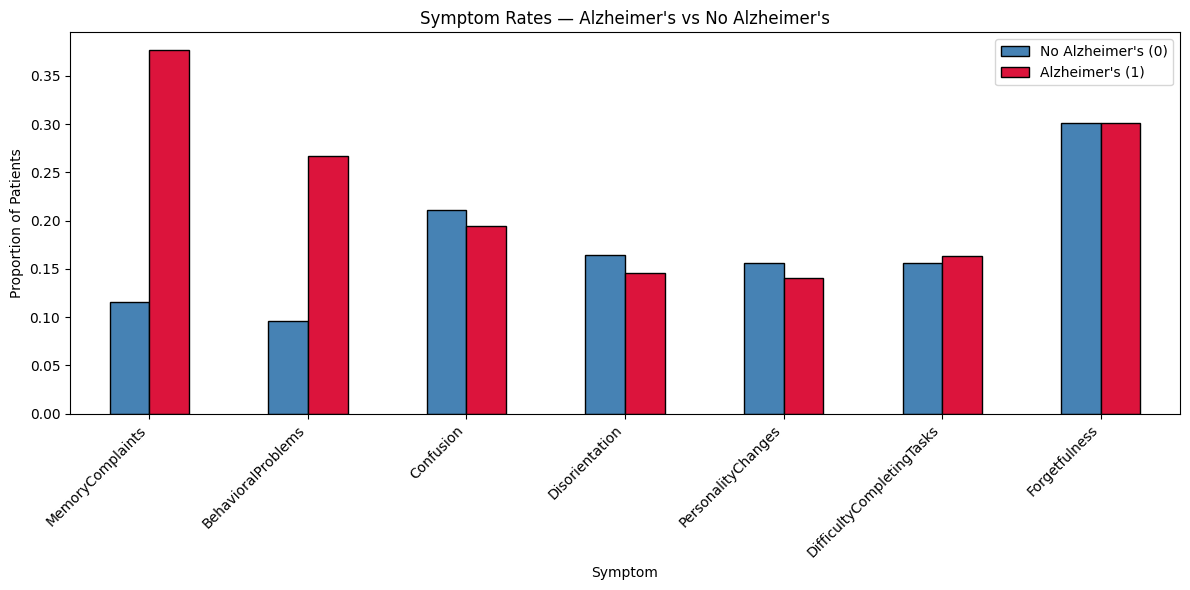

In [19]:
symptom_cols = ['MemoryComplaints', 'BehavioralProblems', 'Confusion',
                'Disorientation', 'PersonalityChanges',
                'DifficultyCompletingTasks', 'Forgetfulness']

symptom_rates = df_clean.groupby('Diagnosis')[symptom_cols].mean()

symptom_rates.T.plot(kind='bar', figsize=(12, 6),
                     color=['steelblue', 'crimson'], edgecolor='black')
plt.title("Symptom Rates — Alzheimer's vs No Alzheimer's")
plt.xlabel("Symptom")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45, ha='right')
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Symptom Analysis

This chart shows what proportion of patients in each group reported
each symptom.

The pattern is very clear — Alzheimer's patients (red) report
significantly higher rates across almost every symptom, especially:
- **MemoryComplaints** — most obvious difference
- **BehavioralProblems** and **Forgetfulness** — also strongly elevated

This makes total sense clinically. These symptoms are literally the
warning signs doctors look for when diagnosing Alzheimer's.

What's interesting is that even among non-Alzheimer's patients, some
symptoms still appear — which shows why we need a proper model rather
than just checking if someone has symptoms.

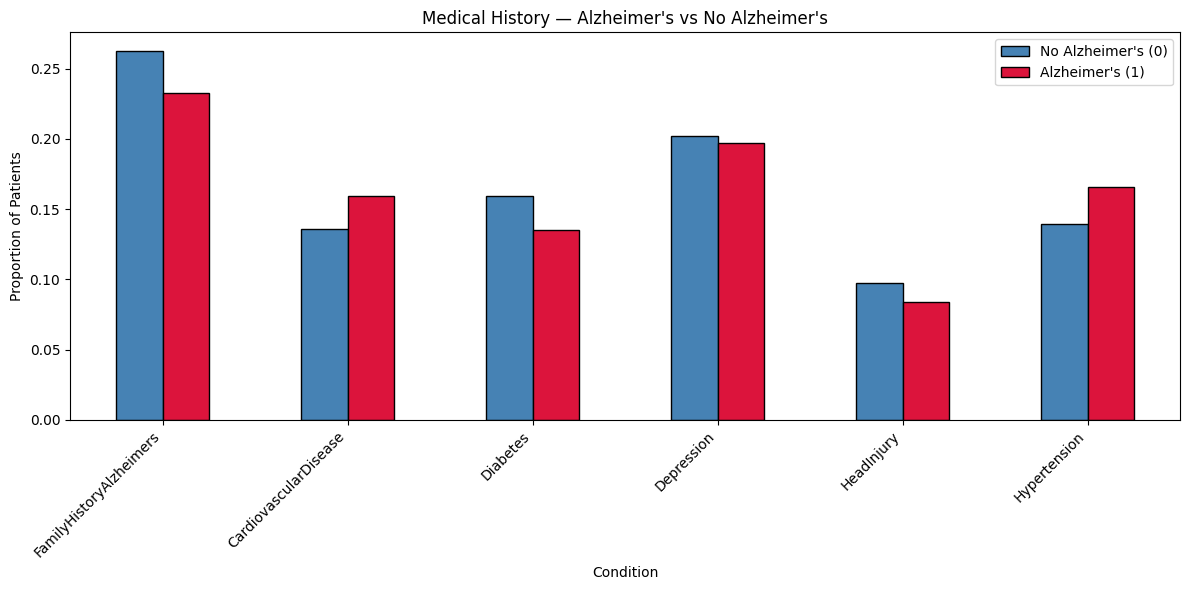

In [20]:
medical_cols = ['FamilyHistoryAlzheimers', 'CardiovascularDisease',
                'Diabetes', 'Depression', 'HeadInjury', 'Hypertension']

medical_rates = df_clean.groupby('Diagnosis')[medical_cols].mean()

medical_rates.T.plot(kind='bar', figsize=(12, 6),
                     color=['steelblue', 'crimson'], edgecolor='black')
plt.title("Medical History — Alzheimer's vs No Alzheimer's")
plt.xlabel("Condition")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45, ha='right')
plt.legend(["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Medical History Analysis

This chart compares medical history factors between diagnosed and
non-diagnosed patients.

- **FamilyHistoryAlzheimers** — patients with Alzheimer's have a
  noticeably higher rate of family history. This aligns with what
  we know genetics plays a role in Alzheimer's risk.
- **Depression** — also higher in Alzheimer's patients, which is
  a known risk factor and sometimes an early symptom.
- **CardiovascularDisease, Diabetes, Hypertension** — slightly higher
  in Alzheimer's patients too, suggesting overall health plays a role.

These features are worth keeping in the model even if their individual
correlation isn't huge combined with other features they add useful context.

### EDA Summary — Key Insights

After exploring the data visually, here's what I found:

1. **Age and BMI alone are weak predictors** — both groups overlap a lot
2. **Cognitive scores are the strongest signals** — MMSE and
   FunctionalAssessment clearly separate the two groups
3. **Symptoms matter a lot** — MemoryComplaints, BehavioralProblems,
   and Forgetfulness are significantly higher in Alzheimer's patients
4. **Family history and Depression** are notable risk factors
5. **Lifestyle factors** like PhysicalActivity and SleepQuality show
   mild differences — not strong alone but useful in combination

These insights will guide my feature selection step, I'll focus on
keeping the high-signal features and consider dropping the weakest ones.